# Import modules

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import datetime
import matplotlib.pyplot as plt

from tx_fast_hydrology.muskingum import Muskingum, ModelCollection
from tx_fast_hydrology.simulation import AsyncSimulation
from tx_fast_hydrology.io import ModelDecoder, ModelEncoder

# Instantiate Muskingum model

In [2]:
model_collection = ModelCollection.from_file('../data/trinity_muskingum.json')
model = model_collection.models['dfw']

# Read HMS data

In [3]:
nhf_path = '/home/akagi/Documents/Data/txswift/nhf_1.1.3.gpkg'
nhf_flowpaths = gpd.read_file(nhf_path, layer='flowpaths').set_index('fp_id')
nhf_subbasins = gpd.read_file(nhf_path, layer='divides').set_index('div_id')
div_to_fp_mapping = nhf_flowpaths.reset_index().set_index('div_id')['fp_id']

In [4]:
# Ensure 1-1 mapping between fp_id and div_id
assert not nhf_flowpaths['div_id'].duplicated().any()

In [5]:
nhf_to_hms_mapping = pd.read_csv('../data/nhf_to_hms_subbasins.csv', index_col=0).set_index('nhf_id')
hms = pd.read_parquet('/home/akagi/Documents/Data/txswift/hms/forecast/lookback.parquet')
hms['timestamp'] = pd.to_datetime(hms['timestamp'], utc=True)
hms = hms[hms['site_id'].isin(nhf_to_hms_mapping['hms_id'])]
excess_precip = hms[hms['variable'] == 'PRECIP-EXCESS'].set_index('timestamp')

# Assign HMS excess precip to flowlines

In [6]:
forcings = []

for nhf_id in nhf_to_hms_mapping.index:
    hms_id = nhf_to_hms_mapping.loc[nhf_id, 'hms_id']
    excess_precip_col = pd.Series(excess_precip[excess_precip['site_id'] == hms_id]['value'], name=nhf_id)
    area = nhf_subbasins.loc[nhf_id, 'area_sqkm']
    runoff_col = area * excess_precip_col
    forcings.append(runoff_col)

forcings = pd.concat(forcings, axis=1)

In [7]:
forcings = forcings.loc[:, forcings.columns.isin(div_to_fp_mapping)]
forcings.columns = forcings.columns.map(div_to_fp_mapping)

In [8]:
assert not forcings.isnull().any().any()

In [9]:
# Only about half of reach IDs are in forcings
pd.Series(np.asarray(model.reach_ids).astype(int)).isin(forcings.columns).sum() / len(model.reach_ids)

np.float64(0.5465542521994134)

In [10]:
# All forcing points are in model reach IDs
pd.Series(forcings.columns).isin(np.asarray(model.reach_ids).astype(int)).sum() / forcings.columns.size

np.float64(1.0)

In [11]:
forcings = forcings.reindex(np.asarray(model.reach_ids).astype(int), axis=1).fillna(0.)
forcings.columns = forcings.columns.astype(str)
forcings = forcings.sort_index()

<Axes: xlabel='timestamp'>

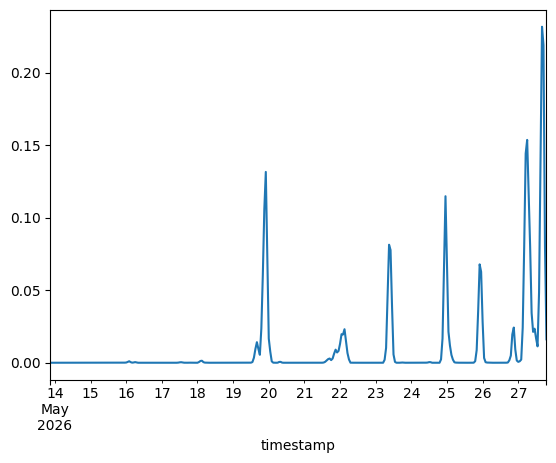

In [12]:
forcings.mean(axis=1).plot()

# Run Muskingum model with HEC-HMS forcings

In [13]:
o_t = np.zeros(model.n)
model.datetime = forcings.index.min()
model.init_states(o_t_next=o_t)

# Add downstream boundaries to model
for model in model_collection.models.values():
    for outlet in model.startnodes[model.startnodes == model.endnodes]:
        model.set_transmissive_boundary(outlet)

In [14]:
outputs = {}

n_steps = len(forcings)
model.datetime = forcings.index.min()
# Step model forward in time
for _ in range(n_steps):
    p_t_next = forcings.asof(model.datetime).values
    model.step(p_t_next)
    o_t = model.o_t
    outputs[model.datetime] = o_t

outputs = pd.DataFrame.from_dict(outputs, orient='index')
outputs.columns = model.reach_ids

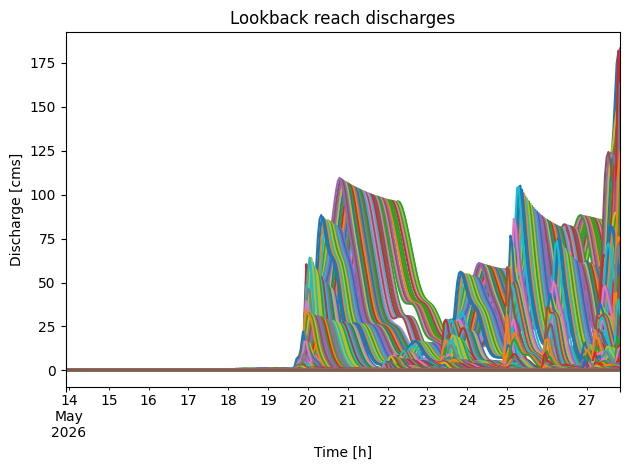

In [15]:
outputs.plot(legend=False)
plt.xlabel('Time [h]')
plt.ylabel('Discharge [cms]')
plt.title('Lookback reach discharges')
plt.tight_layout()

In [16]:
outputs.to_csv('../data/dfw_outputs_hms_forcings.csv')

In [16]:
# Check why simulate_iter and AsyncSimulation are not working